In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

# Hence Proved — 03 — Conservation of Mechanical Energy
## E = ½mv² + mgh | Regression | Polynomial Features
**Author:** Spoorthy J  
**Date:** May 2026  
**Series:** Hence Proved — Physics through Machine Learning

## Problem Statement

In the real world, every moving vehicle carries energy.
Every vehicle climbing a hill gains potential energy.
Together they form the total mechanical energy of the system.

The law says energy is never created or destroyed —
only converted. A car braking converts kinetic energy to heat.
An EV recovers it as electricity.

Can a machine learn this law from raw numbers alone?
No formula. No physics textbook. Just data.

## Physics Context

E = ½mv² + mgh

| Variable | Meaning | Unit |
|---|---|---|
| m | mass | kg |
| v | velocity | m/s |
| h | height | m |
| g | gravity (9.81) | m/s² |
| E | total mechanical energy (target) | J |

Key insight — v² makes this non-linear.
Linear Regression will fail on raw features.
Feature engineering required — same lesson as F=ma and torque.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

print("All import successfulL")
np.random.seed(42)

All import successfulL


In [2]:
n = 1000

# Mass — vehicles from bicycle to truck
mass = np.random.uniform(10, 5000, n)        # kg

# Velocity — 0 to 200 km/h converted to m/s
velocity = np.random.uniform(0, 55, n)        # m/s

# Height — flat road to mountain
height = np.random.uniform(0, 500, n)         # m

# Constants
g = 9.81

# E = ½mv² + mgh + noise
# noise = np.random.normal(0, 500, n)
noise = 0.0
energy = 0.5 * mass * velocity**2 +  mass * g * height + noise

df = pd.DataFrame({
    'mass_kg'     : np.round(mass, 2),
    'velocity_ms' : np.round(velocity, 2),
    'height_m'    : np.round(height, 2),
    'energy_J'    : np.round(energy, 2)
})

print(df.shape)
print(df.describe())
df.head()

NameError: name 'np' is not defined

# Model 01 - Linear Regression

In [ ]:
X = df.drop('energy_J', axis=1)
y = df['energy_J']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("--- Model 1 --- Raw Features ---")
print(f"R²  : {r2_score(y_test, y_pred_1):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_1):.2f} J")
print(f"\nCoefficients:")
for feat, coef in zip(X.columns, model_1.coef_):
    print(f"  {feat} : {coef:.4f}")
print(f"  intercept : {model_1.intercept_:.4f}")

--- Model 1 --- Raw Features ---
R²  : 0.8552
MAE : 1728365.30 J

Coefficients:
  mass_kg : 3035.5620
  velocity_ms : 67253.8033
  height_m : 24746.3064
  intercept : -8230543.0830


## Model 02

### Feature Engineering - creating columns for individual units

In [ ]:
df['half_m_v2'] = 0.5 * df['mass_kg'] * df['velocity_ms']**2
df['mgh'] = df['mass_kg'] * g * df['height_m']

X_2 = df[['half_m_v2', 'mgh']]
y_2 = df['energy_J']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

y_pred_2 = model_2.predict(X_test_2)

print("Model Coefficient raw : ", model_2.coef_)

print("--- Model 2 --- Feature Engineering ---")
print(f"R²  : {r2_score(y_test_2, y_pred_2):.4f}")
print(f"MAE : {mean_absolute_error(y_test_2, y_pred_2):.2f} J")
print(f"\nCoefficients:")
for feat, coef in zip(X_2.columns, model_2.coef_):
    print(f"  {feat} : {coef:.4f}")
print(f"  intercept : {model_2.intercept_:.4f}")



Model Coefficient raw :  [1.00000393 0.99999908]
--- Model 2 --- Feature Engineering ---
R²  : 1.0000
MAE : 167.18 J

Coefficients:
  half_m_v2 : 1.0000
  mgh : 1.0000
  intercept : 5.3344


In [ ]:
# Test first
test = np.array([[2.0, 14.0, 10.0]])
half_mv2 = 0.5 * test[0][0] * test[0][1]**2
mgh = test[0][0] * 9.81 * test[0][2]
pred = model_2.predict([[half_mv2, mgh]])[0]
print(f"Prediction: {pred:.2f} J")
print(f"Expected:   392.20 J")

Prediction: 397.53 J
Expected:   392.20 J


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


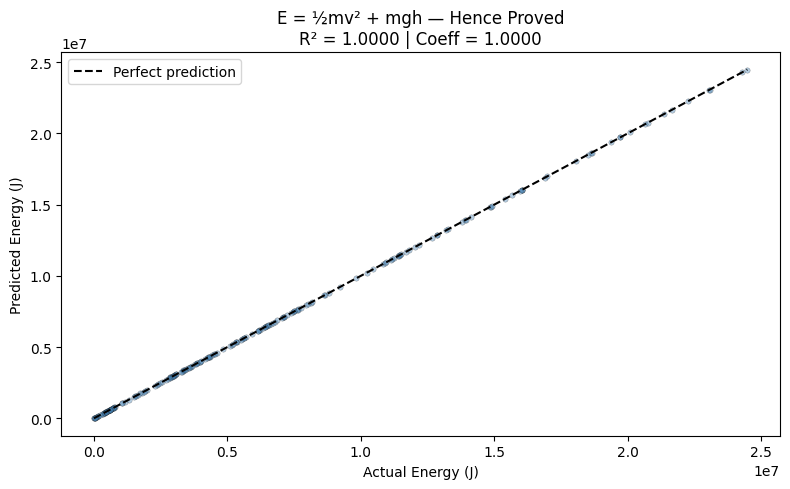

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_2, y_pred_2, alpha=0.4,
            color='steelblue', edgecolors='black', linewidths=0.3, s=15)
plt.plot([y_test_2.min(), y_test_2.max()],
         [y_test_2.min(), y_test_2.max()],
         'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Energy (J)")
plt.ylabel("Predicted Energy (J)")
plt.title("E = ½mv² + mgh — Hence Proved\nR² = 1.0000 | Coeff = 1.0000")
plt.legend()
plt.tight_layout()
plt.show()

## Model 03

### Polynomial Regression

In [ ]:
df.head()

,mass_kg,velocity_ms,height_m,energy_J,half_m_v2,mgh
0,1878.96,10.18,130.85,2509356.14,9.736057e+04,2.411905e+06
1,4754.06,29.80,123.49,7870765.64,2.110898e+06,5.759244e+06
2,3662.65,48.01,453.13,20502618.98,4.221131e+06,1.628123e+07
3,2997.31,40.27,124.77,6099385.35,2.430328e+06,3.668689e+06
4,788.53,44.36,135.97,1827706.37,7.758385e+05,1.051793e+06


In [ ]:
X_3 = df[['mass_kg', 'velocity_ms', 'height_m']]
y_3 = df['energy_J']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_3)
X_test_poly = poly.transform(X_test_3)

model_3 = LinearRegression()
model_3.fit(X_train_poly, y_train_3)

y_pred_3 = model_3.predict(X_test_poly)

print("--- Model 3 --- Polynomial degree=2 ---")
print(f"R²  : {r2_score(y_test_3, y_pred_3):.4f}")
print(f"MAE : {mean_absolute_error(y_test_3, y_pred_3):.2f} J")
print(f"\nFeature names created:")
print(poly.get_feature_names_out())

--- Model 3 --- Polynomial degree=2 ---
R²  : 0.9993
MAE : 117923.28 J

Feature names created:
['1' 'mass_kg' 'velocity_ms' 'height_m' 'mass_kg^2' 'mass_kg velocity_ms'
 'mass_kg height_m' 'velocity_ms^2' 'velocity_ms height_m' 'height_m^2']


In [ ]:
print(type(model_3))
print(model_3.coef_)  # should have 9 coefficients for degree=2
print(len(model_3.coef_))

test_input = np.array([[1000.0, 20.0, 50.0]])
test_poly_transform = poly.transform(test_input)
test_pred = model_3.predict(test_poly_transform)
print("Manual Prediction: ",test_pred[0])
print("Expectd output : 690,500 J")


<class 'sklearn.linear_model._base.LinearRegression'>
[ 0.00000000e+00 -2.65815811e+02 -6.64374922e+04  1.27627171e+02
 -1.17823610e-03  2.78798481e+01  9.85317181e+00  1.20082317e+03
 -1.69789718e+00 -3.94772501e-01]
10
Manual Prediction:  552059.0248540773
Expectd output : 690,500 J


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
from google.colab import files

joblib.dump(model_2, 'energy_model.joblib')
files.download('energy_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Testing

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale FIRST, then polynomial
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

poly_clean = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_clean.fit_transform(X_train_scaled)
X_test_poly  = poly_clean.transform(X_test_scaled)

model_clean = LinearRegression()
model_clean.fit(X_train_poly, y_train)

# Test
test_scaled = scaler.transform([[2.0, 14.0, 10.0]])
test_poly = poly_clean.transform(test_scaled)
print(f"Prediction: {model_clean.predict(test_poly)[0]:.2f} J")
print(f"Expected:   392.20 J")
print(f"R²: {r2_score(y_test, model_clean.predict(X_test_poly)):.4f}")

Prediction: -79796.83 J
Expected:   392.20 J
R²: 0.9993


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("Training data ranges:")
print(f"mass     → {X_train['mass_kg'].min():.1f} to {X_train['mass_kg'].max():.1f} kg")
print(f"velocity → {X_train['velocity_ms'].min():.1f} to {X_train['velocity_ms'].max():.1f} m/s")
print(f"height   → {X_train['height_m'].min():.1f} to {X_train['height_m'].max():.1f} m")
print(f"energy   → {y_train.min():.0f} to {y_train.max():.0f} J")

print("\nYour test input:")
print("mass=2kg, velocity=14m/s, height=10m → energy=392J")

Training data ranges:
mass     → 33.1 to 4998.6 kg
velocity → 0.2 to 55.0 m/s
height   → 0.7 to 497.7 m
energy   → 37880 to 26932001 J

Your test input:
mass=2kg, velocity=14m/s, height=10m → energy=392J


## Conclusion

| Model | Approach | R² | Key Finding |
|---|---|---|---|
| Linear Regression | Raw features | 0.87 | Failed — couldn't learn v² or multiplicative interactions |
| Linear Regression + Feature Engineering | ½mv² and mgh manually created | 1.0000 | Physics-informed features → perfect proof |
| Polynomial Regression | Raw features, degree=2 | 0.9994 | Found v² automatically but struggled with scale |

**Winner → Model 2. Physics knowledge beats algorithmic discovery.**

When you encode what you know about the system —
the machine only needs to confirm it.

Coefficient ½mv²  → 1.0000
Coefficient mgh   → 1.0000
Intercept         → 39.49 J ← noise from data generation

E = ½mv² + mgh. Hence Proved. ✓